In [2]:
library(DBI)
library(RPostgres)
library(tidyverse)
library(glue)
library(httr)
library(jsonlite)
library(dplyr)
library(tidyr)
library(lubridate)
library(stringr)
library(ggplot2)
library(readr)

source("pitcher_profile_functions.r")
source("data_extract_functions.r")


pitcher_id <- 669373
pitcher_scouting_report_df <- pull_pitcher_scouting_report_from_database(pitcher_id)

# grab specific pitch type >= 10% usage

pitcher_pitch_arsenal <- create_pitcher_pitch_arsenal(pitcher_scouting_report_df)

pitcher_statcast_df <- pull_pitcher_statcast_data_from_csv(pitcher_id, pitcher_pitch_arsenal)

pitcher_pitch_usage_df <- create_pitcher_pitch_usage_df(pitcher_statcast_df)

pitcher_pitch_characteristics_df <- create_pitcher_pitch_characteristics_df(pitcher_statcast_df)

pitcher_pitch_performance_df <- create_pitcher_pitch_performance_df(pitcher_statcast_df)

########### plots #####################

pitch_visual_plots <- create_pitcher_pitch_visual_plots(pitcher_statcast_df)

pitch_usage_plots <- create_pitcher_usage_plots(pitcher_pitch_usage_df)

#pitch_characteristics_plots <- create_pitch_characteristics_plots(pitcher_pitch_characteristics_df)

pitch_tendencies_plots <- create_pitch_tendency_plots(pitcher_scouting_report_df)

New names:
• `` -> `...1`


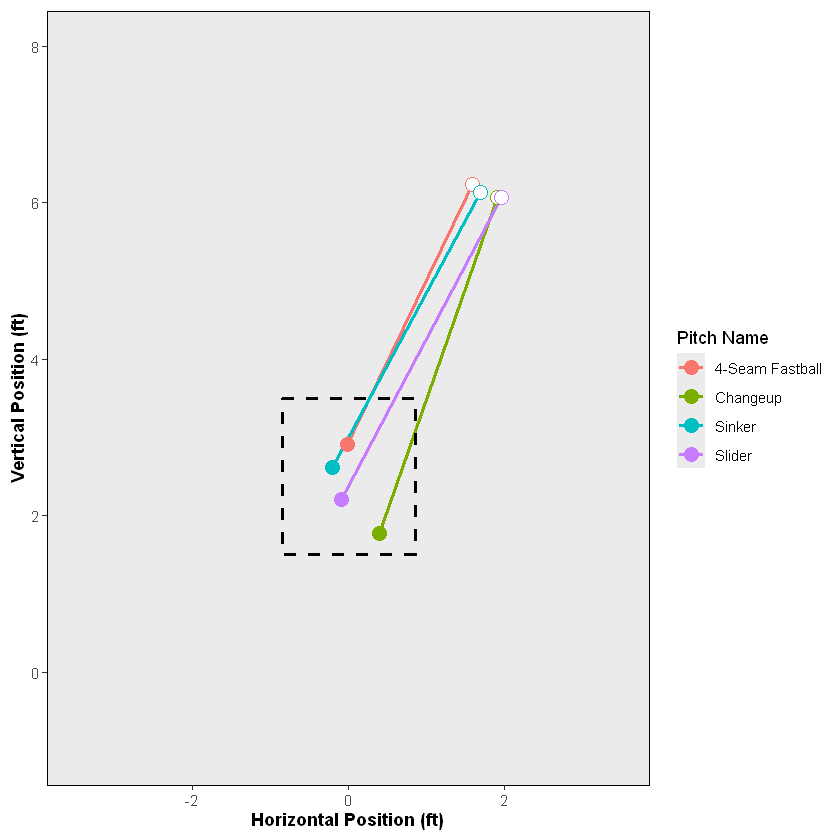

In [144]:
source("pitcher_profile_functions.r")

pitcher_pitch_characteristics_df <- create_pitcher_pitch_characteristics_df(pitcher_statcast_df)




ggplot(pitcher_pitch_characteristics_df, aes(color = pitch_name)) +
  geom_segment(aes(
    x = avg_rel_x, y = avg_rel_z,
    xend = avg_plate_x, yend = avg_plate_z
  ), linewidth = 1) +
  geom_point(aes(x = avg_rel_x, y = avg_rel_z), size = 4, shape = 21, fill = "white") +
  geom_point(aes(x = avg_plate_x, y = avg_plate_z), size = 4) +
  coord_fixed(xlim = c(-3.5, 3.5), ylim = c(-1, 8)) +
  annotate("rect",
           xmin = -0.85, xmax = 0.85,
           ymin = 1.5, ymax = 3.5,
           fill = NA, color = "black",
           linetype = "dashed", linewidth = 1) +
  labs(
    x = "Horizontal Position (ft)",
    y = "Vertical Position (ft)",
    color = 'Pitch Name'
  ) +
  theme(
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold"),
      panel.grid = element_blank(),
      panel.border = element_rect(color = "black", fill = NA))




In [5]:
pitcher_pitch_characteristics_df

pitch_type,pitch_name,avg_velo,avg_rel_x,avg_rel_y,avg_rel_z,avg_hmov,avg_vmov,avg_vx0,avg_vy0,avg_vz0,avg_ax,avg_ay,avg_az,avg_spin
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CH,Changeup,87.97,1.90,54.09,6.07,1.24,0.52,-6.21,-127.87,-5.36,14.86,26.97,-25.50,1834.755
FF,4-Seam Fastball,97.54,1.59,54.05,6.23,0.29,1.43,-4.98,-141.83,-6.69,5.05,32.91,-11.58,2356.345
SI,Sinker,97.30,1.69,54.01,6.13,1.10,1.12,-7.60,-141.39,-6.44,16.45,32.38,-15.84,2248.622
SL,Slider,90.11,1.95,54.03,6.07,-0.27,0.39,-4.53,-131.18,-4.49,-2.22,26.05,-26.93,2240.862
